# YOLOv8s Door / Tree / Stairs Dataset + Training Notebook

This notebook downloads **Door**, **Tree**, and **Stairs** images from Open Images using FiftyOne, keeps the bounding boxes, balances the dataset by image count, exports it in YOLO format to Google Drive, runs sanity checks, and trains YOLOv8s.

Recommended Colab runtime: **GPU**.

## 0. Install packages

In [ ]:
!pip install -q fiftyone ultralytics

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 98.8 MB/s eta 0:00:00

## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Download balanced source datasets with bounding boxes

This downloads more samples than needed because some classes, especially **Stairs**, can be rarer.

In [ ]:
import fiftyone as fo
import fiftyone.zoo as foz
from collections import Counter
import random

CLASSES = ["Door", "Tree", "Stairs"]

# Target number of IMAGES per class in the final balanced dataset
TARGET_IMAGES_PER_CLASS = 1500

# Request more than target because Open Images may not return enough clean samples
MAX_DOWNLOAD_PER_CLASS = {
    "Door": 3000,
    "Tree": 3000,
    "Stairs": 7000,
}

random.seed(42)

downloaded_datasets = {}

for cls in CLASSES:
    dataset_name = f"openimages_{cls.lower()}_raw"

    if fo.dataset_exists(dataset_name):
        fo.delete_dataset(dataset_name)

    print(f"Downloading {cls}...")

    ds = foz.load_zoo_dataset(
        "open-images-v7",
        split="train",
        label_types=["detections"],
        classes=[cls],
        max_samples=MAX_DOWNLOAD_PER_CLASS[cls],
        only_matching=True,
        dataset_name=dataset_name,
    )

    downloaded_datasets[cls] = ds
    print(f"{cls}: downloaded {len(ds)} images")

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/open-images-v7/train' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv' to '/root/fiftyone/open-images-v7/train/metadata/image_ids.csv'


 100% |██████|    4.8Gb/4.8Gb [2.4s elapsed, 0s remaining, 1.8Gb/s]        


INFO:eta.core.utils: 100% |██████|    4.8Gb/4.8Gb [2.4s elapsed, 0s remaining, 1.8Gb/s]        


...

 100% |███████████████| 4533/4533 [11.1s elapsed, 0s remaining, 421.5 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 4533/4533 [11.1s elapsed, 0s remaining, 421.5 samples/s]      


Dataset 'openimages_stairs_raw' created


INFO:fiftyone.zoo.datasets:Dataset 'openimages_stairs_raw' created


Stairs: downloaded 4533 images


## 3. Create one balanced dataset

This selects the same target number of images per class and avoids duplicate filepaths.

In [ ]:
balanced_name = "door_tree_stairs_balanced"

if fo.dataset_exists(balanced_name):
    fo.delete_dataset(balanced_name)

balanced = fo.Dataset(balanced_name)
used_filepaths = set()

for cls in CLASSES:
    ds = downloaded_datasets[cls]
    matching_samples = []

    for sample in ds:
        if sample.filepath in used_filepaths:
            continue

        if sample.ground_truth is None:
            continue

        has_class = any(det.label == cls for det in sample.ground_truth.detections)

        if has_class:
            matching_samples.append(sample)

    random.shuffle(matching_samples)
    selected = matching_samples[:TARGET_IMAGES_PER_CLASS]

    print(f"{cls}: selected {len(selected)} images")

    for sample in selected:
        used_filepaths.add(sample.filepath)
        balanced.add_sample(sample.copy())

print("Final balanced dataset:")
print(balanced)
print("Total images:", len(balanced))

Door: selected 1500 images
Tree: selected 1500 images
Stairs: selected 1500 images
Final balanced dataset:
Name:        door_tree_stairs_balanced
Media type:  image
Num samples: 4500
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
Total images: 4500


## 4. Check image and box counts per class

Image counts should be close to equal. Box counts do not need to be equal because one image may contain multiple objects.

In [ ]:
def image_count_per_class(dataset):
    counts = Counter()

    for sample in dataset:
        labels_in_image = set()

        if sample.ground_truth is not None:
            for det in sample.ground_truth.detections:
                if det.label in CLASSES:
                    labels_in_image.add(det.label)

        for label in labels_in_image:
            counts[label] += 1

    return counts


def box_count_per_class(dataset):
    counts = Counter()

    for sample in dataset:
        if sample.ground_truth is not None:
            for det in sample.ground_truth.detections:
                if det.label in CLASSES:
                    counts[det.label] += 1

    return counts

print("Image counts per class:")
print(image_count_per_class(balanced))

print("Bounding box counts per class:")
print(box_count_per_class(balanced))

Image counts per class:
Counter({'Door': 1500, 'Tree': 1500, 'Stairs': 1500})
Bounding box counts per class:
Counter({'Tree': 5203, 'Door': 2145, 'Stairs': 1965})


## 5. Split into train and validation

In [ ]:
import fiftyone.utils.random as four

balanced.shuffle(seed=42)

four.random_split(
    balanced,
    {"train": 0.8, "val": 0.2},
    seed=42,
)

print("Split counts:")
print(balanced.count_values("tags"))

train_view = balanced.match_tags("train")
val_view = balanced.match_tags("val")

print("Train images:", len(train_view))
print("Val images:", len(val_view))

Split counts:
{'train': 4500, 'val': 900}
Train images: 4500
Val images: 900


## 6. Export manually to YOLO format in Google Drive

This creates:

```text
images/train
images/val
labels/train
labels/val
data.yaml
```

In [ ]:
import os
import shutil
from pathlib import Path

EXPORT_DIR = Path("/content/drive/MyDrive/yolov8_door_tree_stairs_balanced")

class_to_id = {
    "Door": 0,
    "Tree": 1,
    "Stairs": 2,
}

# Delete previous export to avoid mixing old files
if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)

for split in ["train", "val"]:
    (EXPORT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (EXPORT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)


def export_yolo_split(view, split):
    exported_images = 0
    exported_labels = 0
    skipped_no_label = 0

    for sample in view:
        src_img = Path(sample.filepath)

        # Unique file name to avoid duplicate filename conflicts
        new_img_name = f"{sample.id}{src_img.suffix.lower()}"
        new_label_name = f"{sample.id}.txt"

        dst_img = EXPORT_DIR / "images" / split / new_img_name
        dst_label = EXPORT_DIR / "labels" / split / new_label_name

        lines = []

        if sample.ground_truth is not None:
            for det in sample.ground_truth.detections:
                if det.label not in class_to_id:
                    continue

                cls_id = class_to_id[det.label]

                # FiftyOne bbox format:
                # [top-left-x, top-left-y, width, height], normalized 0-1
                x, y, w, h = det.bounding_box

                x_center = x + (w / 2)
                y_center = y + (h / 2)

                # YOLO format:
                # class_id x_center y_center width height
                lines.append(
                    f"{cls_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}"
                )

        if len(lines) == 0:
            skipped_no_label += 1
            continue

        shutil.copy2(src_img, dst_img)

        with open(dst_label, "w") as f:
            f.write("".join(lines))

        exported_images += 1
        exported_labels += 1

    print(f"{split}: exported {exported_images} images")
    print(f"{split}: exported {exported_labels} labels")
    print(f"{split}: skipped {skipped_no_label} images with no valid labels")


export_yolo_split(train_view, "train")
export_yolo_split(val_view, "val")

print("Exported to:", EXPORT_DIR)

train: exported 4500 images
train: exported 4500 labels
train: skipped 0 images with no valid labels
val: exported 900 images
val: exported 900 labels
val: skipped 0 images with no valid labels
Exported to: /content/drive/MyDrive/yolov8_door_tree_stairs_balanced


## 7. Create `data.yaml`

In [ ]:
yaml_content = f"""
path: {EXPORT_DIR}
train: images/train
val: images/val

names:
  0: Door
  1: Tree
  2: Stairs
"""

yaml_path = EXPORT_DIR / "data.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(yaml_content)
print("Saved:", yaml_path)


path: /content/drive/MyDrive/yolov8_door_tree_stairs_balanced
train: images/train
val: images/val

names:
  0: Door
  1: Tree
  2: Stairs

Saved: /content/drive/MyDrive/yolov8_door_tree_stairs_balanced/data.yaml


## 8. Full sanity check

Run this before training. You want:

- Train images = Train labels
- Val images = Val labels
- Missing labels = 0
- Extra labels = 0
- Bad files = 0

In [ ]:
from pathlib import Path
from collections import Counter

DATASET_DIR = EXPORT_DIR

print("Dataset exists:", DATASET_DIR.exists())
print("Dataset path:", DATASET_DIR)

required_dirs = [
    DATASET_DIR / "images/train",
    DATASET_DIR / "images/val",
    DATASET_DIR / "labels/train",
    DATASET_DIR / "labels/val",
]

print("Folder check:")
for d in required_dirs:
    print(d, "✅" if d.exists() else "❌")

image_exts = [".jpg", ".jpeg", ".png"]

train_images = [p for p in (DATASET_DIR / "images/train").glob("*") if p.suffix.lower() in image_exts]
val_images = [p for p in (DATASET_DIR / "images/val").glob("*") if p.suffix.lower() in image_exts]

train_labels = list((DATASET_DIR / "labels/train").glob("*.txt"))
val_labels = list((DATASET_DIR / "labels/val").glob("*.txt"))

print("Counts:")
print("Train images:", len(train_images))
print("Train labels:", len(train_labels))
print("Val images:", len(val_images))
print("Val labels:", len(val_labels))

print("Image-label count match:")
print("Train:", "✅" if len(train_images) == len(train_labels) else "❌")
print("Val:", "✅" if len(val_images) == len(val_labels) else "❌")


def check_matching(images, labels, split):
    image_stems = set(p.stem for p in images)
    label_stems = set(p.stem for p in labels)

    missing_labels = image_stems - label_stems
    extra_labels = label_stems - image_stems

    print(f"{split} matching check:")
    print("Missing labels:", len(missing_labels))
    print("Extra labels:", len(extra_labels))

    if missing_labels:
        print("Example missing labels:", list(missing_labels)[:5])
    if extra_labels:
        print("Example extra labels:", list(extra_labels)[:5])


check_matching(train_images, train_labels, "Train")
check_matching(val_images, val_labels, "Val")


def check_label_format(label_files, split):
    bad_files = []
    class_counts = Counter()

    for label_file in label_files:
        lines = label_file.read_text().strip().splitlines()

        if len(lines) == 0:
            bad_files.append((label_file, "empty"))
            continue

        for line in lines:
            parts = line.split()

            if len(parts) != 5:
                bad_files.append((label_file, f"wrong number of values: {line}"))
                continue

            cls, x, y, w, h = parts

            try:
                cls = int(cls)
                x, y, w, h = map(float, [x, y, w, h])
            except Exception:
                bad_files.append((label_file, f"not numeric: {line}"))
                continue

            if cls not in [0, 1, 2]:
                bad_files.append((label_file, f"bad class id: {cls}"))

            if not (0 <= x <= 1 and 0 <= y <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
                bad_files.append((label_file, f"bbox outside 0-1: {line}"))

            class_counts[cls] += 1

    print(f"{split} label format check:")
    print("Bad files:", len(bad_files))
    print("Class box counts:", dict(class_counts))

    if bad_files:
        print("Examples:")
        for item in bad_files[:5]:
            print(item)


check_label_format(train_labels, "Train")
check_label_format(val_labels, "Val")

print("data.yaml exists:", (DATASET_DIR / "data.yaml").exists())
print("--- data.yaml ---")
print((DATASET_DIR / "data.yaml").read_text())

Dataset exists: True
Dataset path: /content/drive/MyDrive/yolov8_door_tree_stairs_balanced
Folder check:
/content/drive/MyDrive/yolov8_door_tree_stairs_balanced/images/train ✅
/content/drive/MyDrive/yolov8_door_tree_stairs_balanced/images/val ✅
/content/drive/MyDrive/yolov8_door_tree_stairs_balanced/labels/train ✅
/content/drive/MyDrive/yolov8_door_tree_stairs_balanced/labels/val ✅
Counts:
Train images: 4500
Train labels: 4500
Val images: 900
Val labels: 900
Image-label count match:
Train: ✅
Val: ✅
Train matching check:
Missing labels: 0
Extra labels: 0
Val matching check:
Missing labels: 0
Extra labels: 0
Train label format check:
Bad files: 1698
Class box counts: {0: 1071, 1: 525, 2: 1206}
Examples:
(PosixPath('/content/drive/MyDrive/yolov8_door_tree_stairs_balanced/labels/train/6a0617c71b8ca623cbebd780.txt'), 'wrong number of values: 0 0.394687 0.511667 0.056875 0.9750000 0.885000 0.499584 0.153750 0.999167')
(PosixPath('/content/drive/MyDrive/yolov8_door_tree_stairs_balanced/labels

## 9. Train YOLOv8s

Run this only after the sanity check is good.

In [ ]:
# =========================
# Runtime setup + Drive load
# =========================

!pip install -q ultralytics pyyaml

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

from pathlib import Path
from collections import Counter
import yaml
import os

DATASET_DIR = Path("/content/drive/MyDrive/yolov8_door_tree_stairs_balanced")
DATA_YAML = DATASET_DIR / "data.yaml"

print("Dataset dir:", DATASET_DIR)
print("Dataset exists:", DATASET_DIR.exists())
print("data.yaml exists:", DATA_YAML.exists())

# Required folders
required_dirs = [
    DATASET_DIR / "images/train",
    DATASET_DIR / "images/val",
    DATASET_DIR / "labels/train",
    DATASET_DIR / "labels/val",
]

print("\nFolder check:")
for d in required_dirs:
    print(d, "✅" if d.exists() else "❌")

# Count files
image_exts = [".jpg", ".jpeg", ".png"]

train_images = [p for p in (DATASET_DIR / "images/train").glob("*") if p.suffix.lower() in image_exts]
val_images   = [p for p in (DATASET_DIR / "images/val").glob("*") if p.suffix.lower() in image_exts]

train_labels = list((DATASET_DIR / "labels/train").glob("*.txt"))
val_labels   = list((DATASET_DIR / "labels/val").glob("*.txt"))

print("\nImage / label counts:")
print("Train images:", len(train_images))
print("Train labels:", len(train_labels))
print("Val images:", len(val_images))
print("Val labels:", len(val_labels))

print("\nImage-label count match:")
print("Train:", "✅" if len(train_images) == len(train_labels) else "❌")
print("Val:", "✅" if len(val_images) == len(val_labels) else "❌")

# Matching image stems and label stems
def check_matching(images, labels, split):
    image_stems = set(p.stem for p in images)
    label_stems = set(p.stem for p in labels)

    missing_labels = image_stems - label_stems
    extra_labels = label_stems - image_stems

    print(f"\n{split} matching:")
    print("Missing labels:", len(missing_labels))
    print("Extra labels:", len(extra_labels))

    if missing_labels:
        print("Example missing:", list(missing_labels)[:5])
    if extra_labels:
        print("Example extra:", list(extra_labels)[:5])

check_matching(train_images, train_labels, "Train")
check_matching(val_images, val_labels, "Val")

# Read YAML
print("\n--- data.yaml ---")
if DATA_YAML.exists():
    print(DATA_YAML.read_text())
else:
    print("❌ data.yaml missing")

# GPU check
print("\n--- GPU ---")
!nvidia-smi

Mounted at /content/drive
Dataset dir: /content/drive/MyDrive/yolov8_door_tree_stairs_balanced
Dataset exists: True
data.yaml exists: True

Folder check:
/content/drive/MyDrive/yolov8_door_tree_stairs_balanced/images/train ✅
/content/drive/MyDrive/yolov8_door_tree_stairs_balanced/images/val ✅
/content/drive/MyDrive/yolov8_door_tree_stairs_balanced/labels/train ✅
/content/drive/MyDrive/yolov8_door_tree_stairs_balanced/labels/val ✅

Image / label counts:
Train images: 4500
Train labels: 4500
Val images: 900
Val labels: 900

Image-label count match:
Train: ✅
Val: ✅

Train matching:
Missing labels: 0
Extra labels: 0

Val matching:
Missing labels: 0
Extra labels: 0

--- data.yaml ---

path: /content/drive/MyDrive/yolov8_door_tree_stairs_balanced
train: images/train
val: images/val

names:
  0: Door
  1: Tree
  2: Stairs


--- GPU ---
Thu May 14 19:04:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07             

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

results = model.train(
    data="/content/drive/MyDrive/yolov8_door_tree_stairs_balanced/data.yaml",
    epochs=80,
    imgsz=640,
    batch=64,          # strong GPU, should handle this
    device=0,
    workers=8,
    cache=True,        # faster if RAM/storage allows
    patience=20,
    project="/content/drive/MyDrive/yolov8_training_runs",
    name="door_tree_stairs_balanced_yolov8s_blackwell"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/yolov8_door_tree_stairs_balanced/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fractio

## 10. Show training graphs

After training, Ultralytics saves graphs and CSV metrics in the run folder.

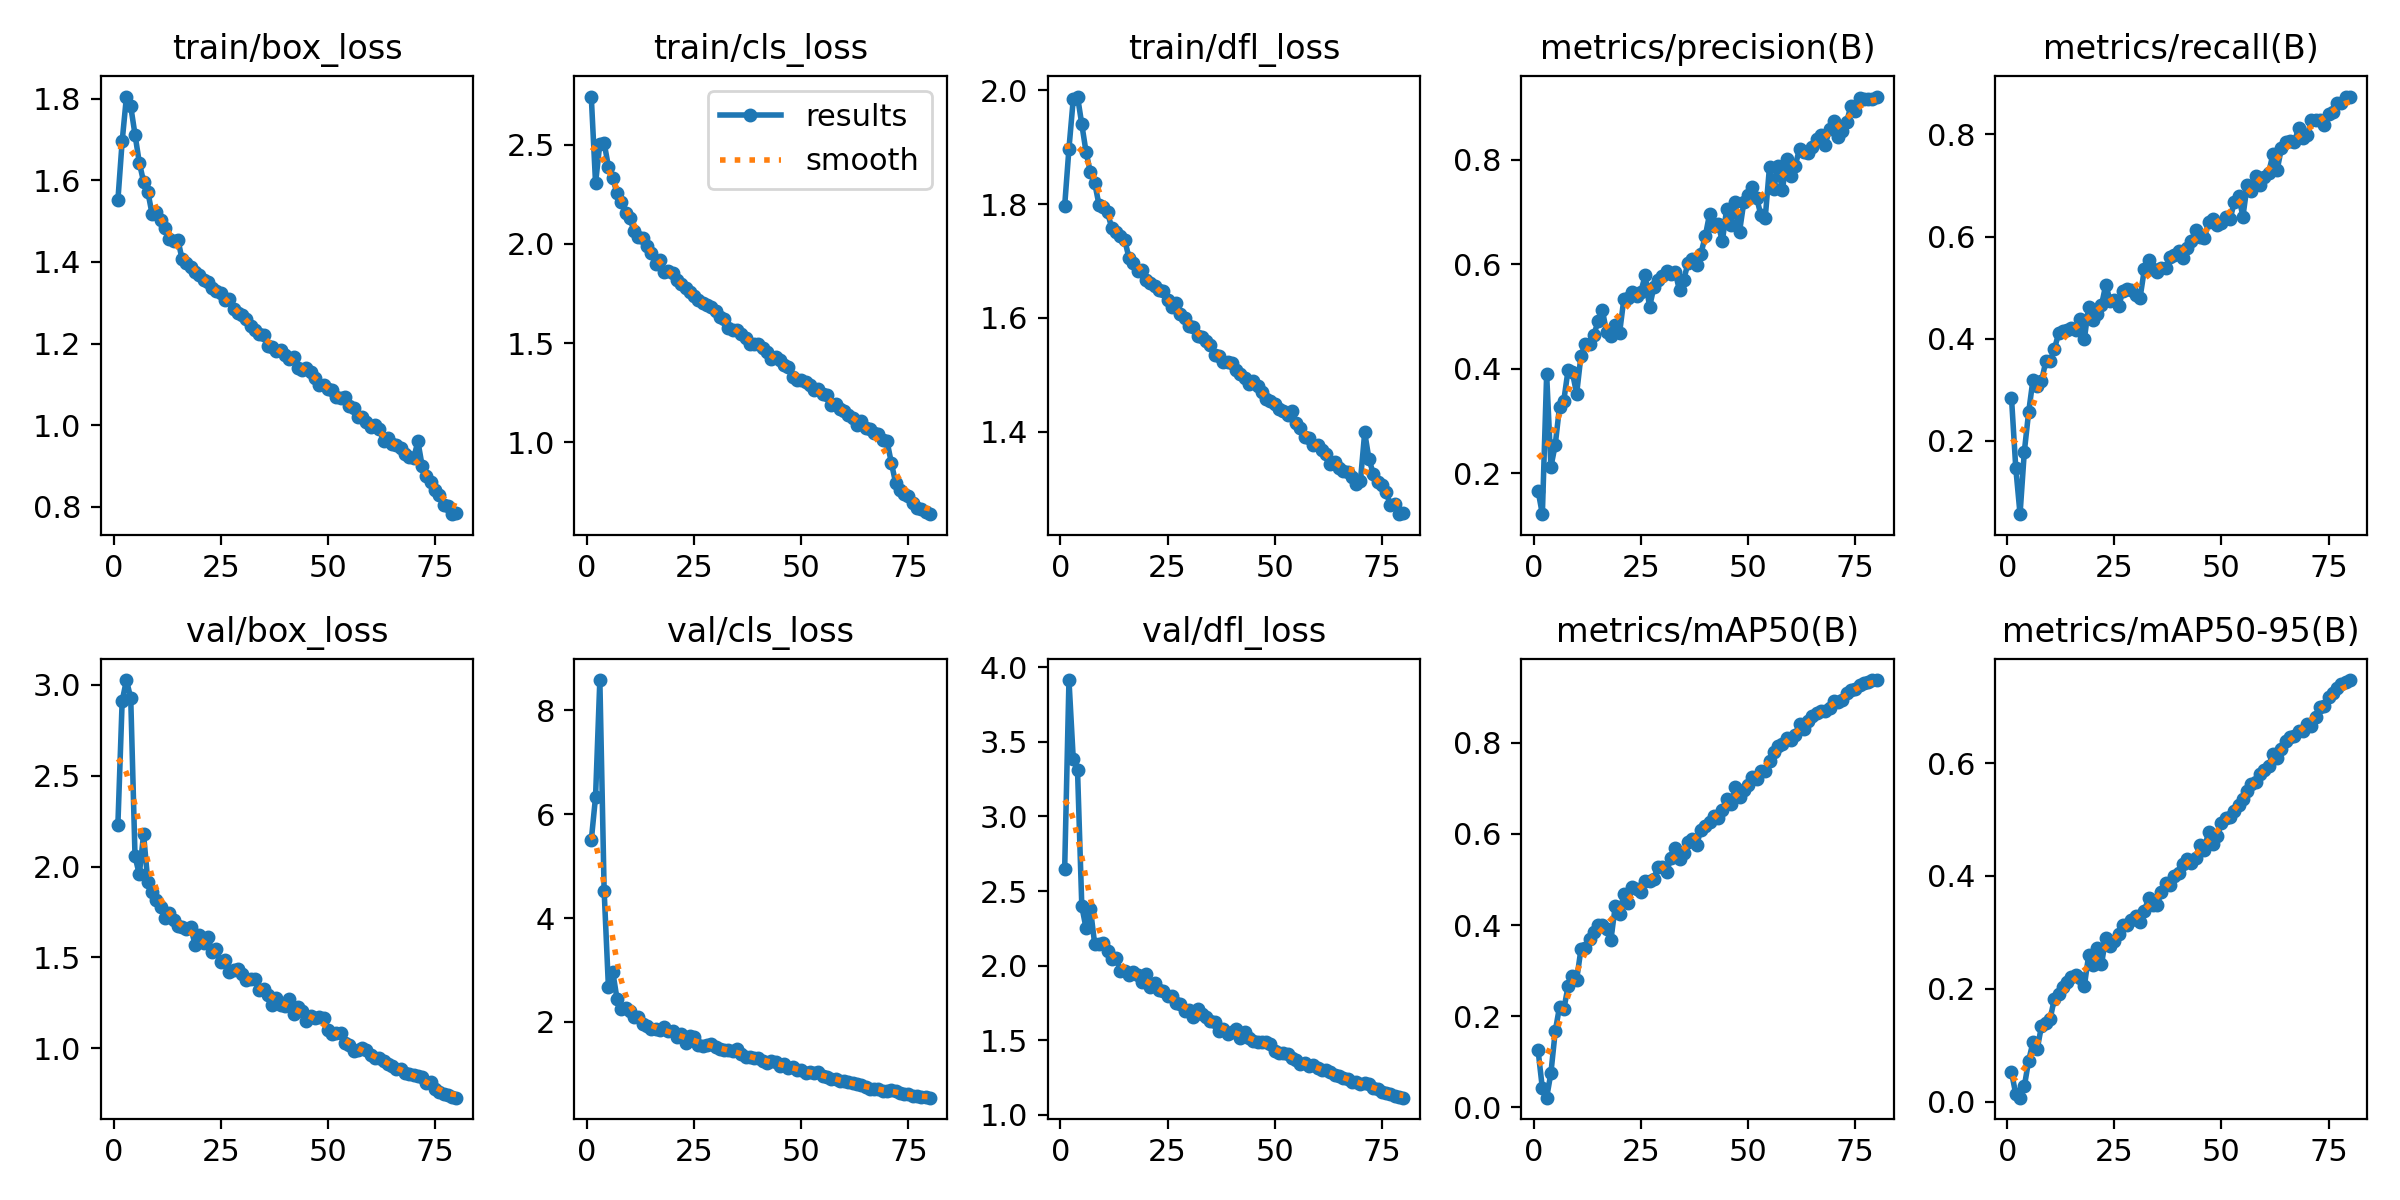

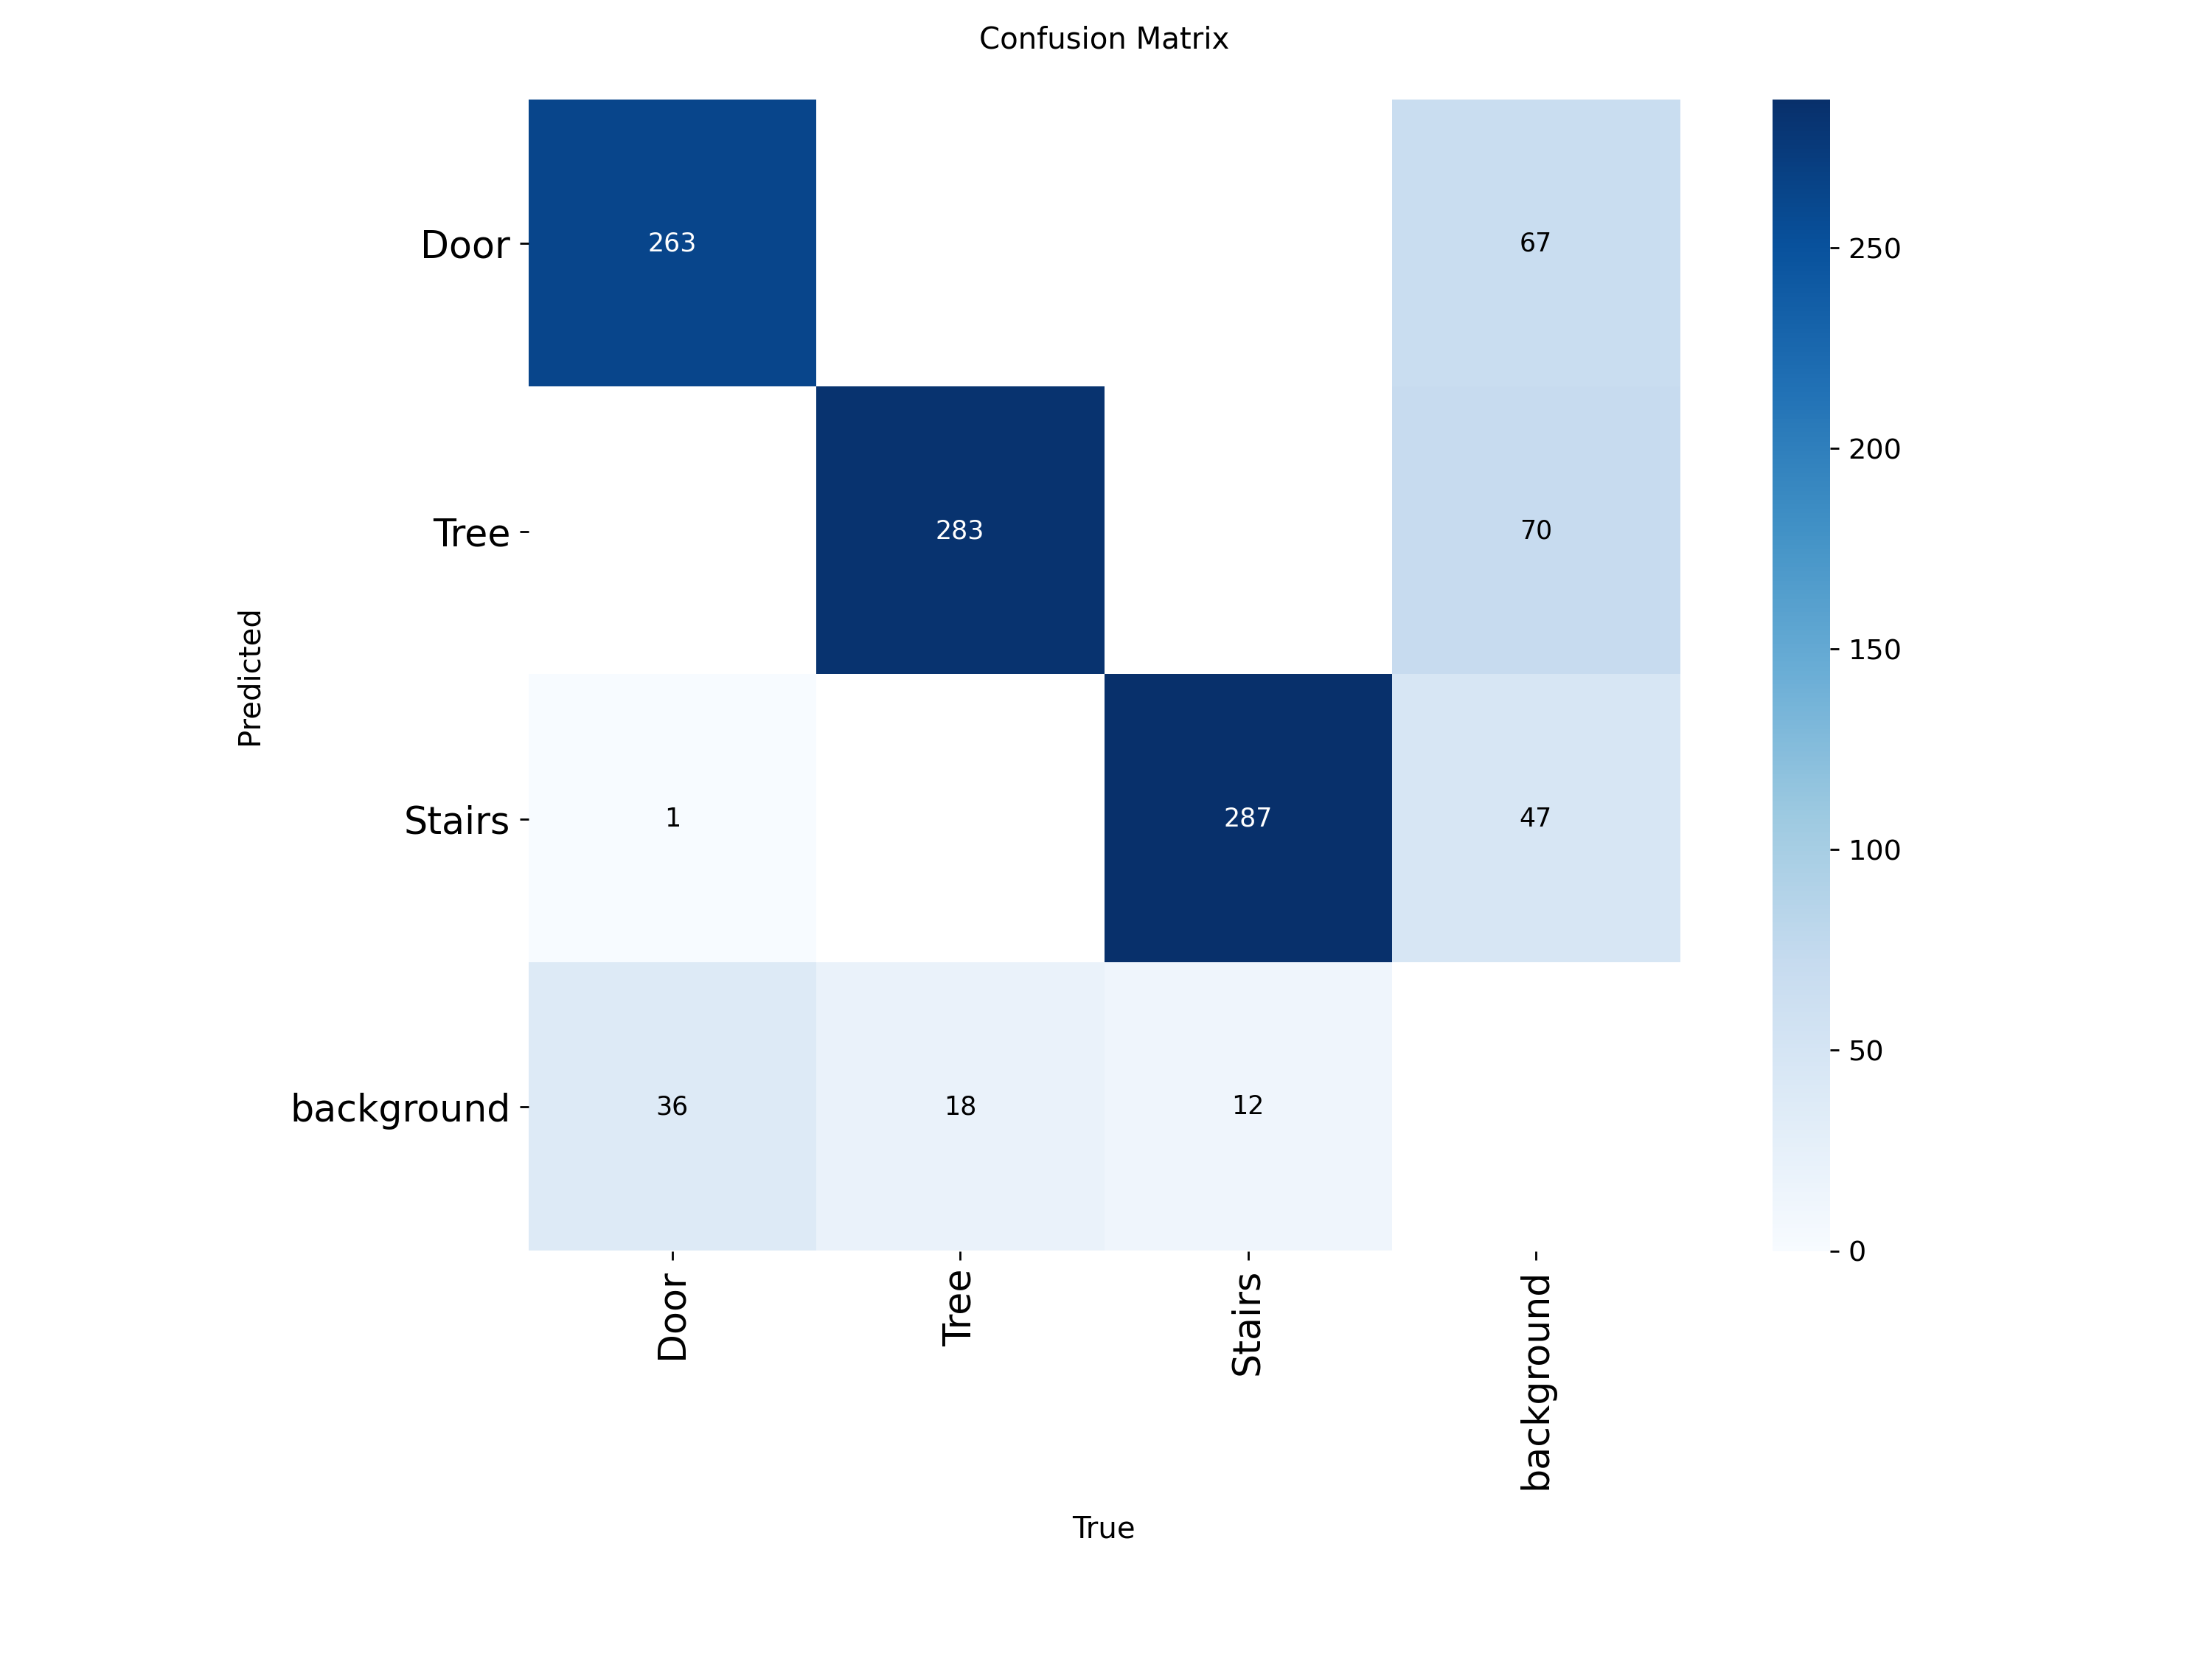

In [ ]:

from IPython.display import Image, display
from pathlib import Path

RUN_DIR = Path("/content/drive/MyDrive/yolov8_training_runs/door_tree_stairs_balanced_yolov8s_blackwell")

results_png = RUN_DIR / "results.png"
conf_matrix = RUN_DIR / "confusion_matrix.png"

if results_png.exists():
    display(Image(filename=str(results_png)))
else:
    print("results.png not found yet:", results_png)

if conf_matrix.exists():
    display(Image(filename=str(conf_matrix)))
else:
    print("confusion_matrix.png not found yet:", conf_matrix)

## 11. Plot metrics manually from `results.csv`

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,14.8935,1.55067,2.74223,1.79703,0.16697,0.28496,0.12523,0.05246,2.22884,5.49539,2.64910,0.000470,0.000470,0.000470
1,2,27.3301,1.69526,2.30548,1.89770,0.12214,0.14767,0.04168,0.01325,2.91093,6.33531,3.91375,0.000934,0.000934,0.000934
2,3,39.7553,1.80499,2.50428,1.98438,0.38937,0.05680,0.02127,0.00696,3.02657,8.58251,3.38542,0.001387,0.001387,0.001387
3,4,52.0567,1.78103,2.50904,1.98909,0.21300,0.17921,0.07563,0.02706,2.92711,4.52987,3.30770,0.001376,0.001376,0.001376
4,5,64.3912,1.71161,2.38902,1.94001,0.25436,0.25587,0.16672,0.07224,2.05616,2.67086,2.39643,0.001358,0.001358,0.001358


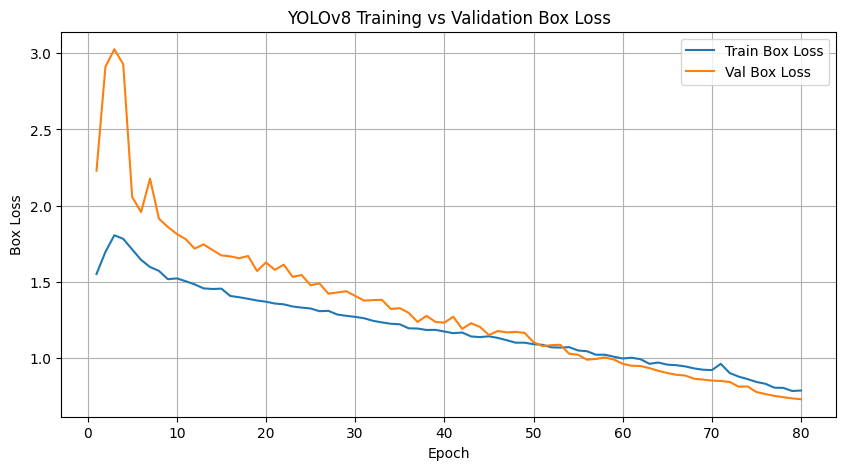

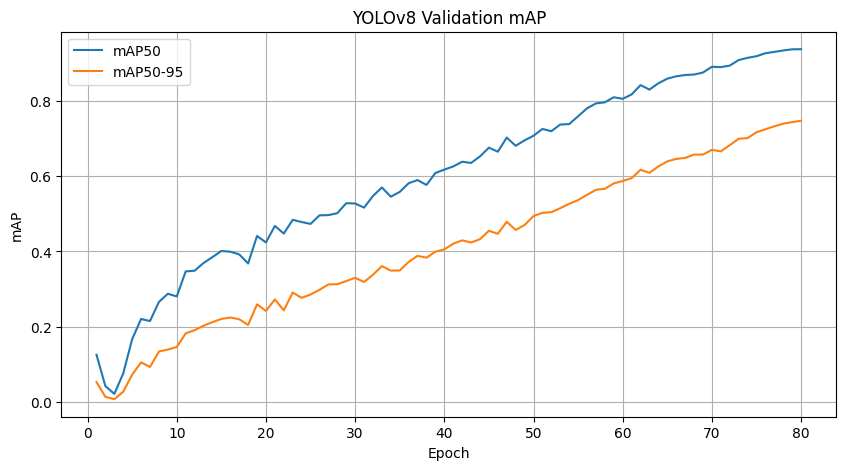

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

RUN_DIR = Path("/content/drive/MyDrive/yolov8_training_runs/door_tree_stairs_balanced_yolov8s_blackwell")
csv_path = RUN_DIR / "results.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    display(df.head())

    plt.figure(figsize=(10, 5))
    plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
    plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Box Loss")
    plt.title("YOLOv8 Training vs Validation Box Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
    plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
    plt.xlabel("Epoch")
    plt.ylabel("mAP")
    plt.title("YOLOv8 Validation mAP")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("results.csv not found yet:", csv_path)

## 12. Test the trained model on one image

In [ ]:

from ultralytics import YOLO
from pathlib import Path
from IPython.display import Image, display

best_model_path = "/content/drive/MyDrive/yolov8_training_runs/door_tree_stairs_balanced_yolov8s_blackwell/weights/best.pt"
model = YOLO(best_model_path)

# Pick one validation image
val_img_dir = Path("/content/drive/MyDrive/yolov8_door_tree_stairs_balanced/images/val")
val_images = list(val_img_dir.glob("*.jpg")) + list(val_img_dir.glob("*.png")) + list(val_img_dir.glob("*.jpeg"))

if val_images:
    test_img = str(val_images[0])
    results = model.predict(test_img, conf=0.25, save=True)
    print("Test image:", test_img)
else:
    print("No validation images found.")


image 1/1 /content/drive/MyDrive/yolov8_door_tree_stairs_balanced/images/val/6a0617cb1b8ca623cbebe477.jpg: 512x640 1 Door, 1 Tree, 14.5ms
Speed: 1.0ms preprocess, 14.5ms inference, 0.6ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /content/runs/detect/predict
Test image: /content/drive/MyDrive/yolov8_door_tree_stairs_balanced/images/val/6a0617cb1b8ca623cbebe477.jpg


In [ ]:
from ultralytics import YOLO

last_ckpt = "/content/drive/MyDrive/yolov8_training_runs/door_tree_stairs_balanced_yolov8s_blackwell/weights/last.pt"

model = YOLO(last_ckpt)

results = model.train(
    data="/content/drive/MyDrive/yolov8_door_tree_stairs_balanced/data.yaml",
    epochs=40,          # adds 40 more epochs as a new run
    imgsz=640,
    batch=64,
    device=0,
    workers=8,
    cache=True,
    patience=15,
    project="/content/drive/MyDrive/yolov8_training_runs",
    name="door_tree_stairs_balanced_yolov8s_blackwell_continue"
)

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/yolov8_door_tree_stairs_balanced/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolov8_training_runs/door_tree_stairs_balanced_yolov8s_blackwell/weights/

In [ ]:
from ultralytics import YOLO

data_yaml = "/content/drive/MyDrive/yolov8_door_tree_stairs_balanced/data.yaml"

old_best_path = "/content/drive/MyDrive/yolov8_training_runs/door_tree_stairs_balanced_yolov8s_blackwell/weights/best.pt"
new_best_path = "/content/drive/MyDrive/yolov8_training_runs/door_tree_stairs_balanced_yolov8s_blackwell_continue/weights/best.pt"

print("OLD BEST:")
old_model = YOLO(old_best_path)
old_metrics = old_model.val(data=data_yaml, imgsz=640, device=0)

print("\nNEW CONTINUED BEST:")
new_model = YOLO(new_best_path)
new_metrics = new_model.val(data=data_yaml, imgsz=640, device=0)

OLD BEST:
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 472.5±309.0 MB/s, size: 336.5 KB)
val: Scanning /content/drive/MyDrive/yolov8_door_tree_stairs_balanced/labels/val.cache... 900 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 900/900 471.9Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 360, len(boxes) = 900. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 16.4it/s 3.5s
                   all        900        900      0.916      0.875      0.937      0.746
                  Door        300        300  

## 13. Final note for the demo

For your demo system, use two models together:

```text
Original yolov8s.pt -> normal COCO classes
Your best.pt -> Door, Tree, Stairs
```

This gives the practical effect of YOLO's normal classes plus the 3 custom navigation classes.